In [1]:
pip install hdbscan

   ---------------------------------------- 0.0/670.6 kB ? eta -:--:--
   --------------- ------------------------ 262.1/670.6 kB ? eta -:--:--
   ------------------------------- -------- 524.3/670.6 kB 1.7 MB/s eta 0:00:01
   ------------------------------- -------- 524.3/670.6 kB 1.7 MB/s eta 0:00:01
   -------------------------------------- 670.6/670.6 kB 791.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 1.5 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.0 MB 1.7 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.0 MB 1.9 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.0 MB 2.1 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.0 MB 1.9 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.0 MB 2.1 MB/s eta 0:00:03
   ---------------- --


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install geopandas 
!pip install contextily
!pip install shapely


   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.9 MB ? eta -:--:--
   - -------------------------------------- 1.0/22.9 MB 3.1 MB/s eta 0:00:07
   -- ------------------------------------- 1.6/22.9 MB 3.1 MB/s eta 0:00:07
   --- ------------------------------------ 2.1/22.9 MB 2.9 MB/s eta 0:00:08
   ----- ---------------------------------- 2.9/22.9 MB 2.9 MB/s eta 0:00:07
   ----- ---------------------------------- 3.4/22.9 MB 3.0 MB/s eta 0:00:07
   ------ --------------------------------- 3.9/22.9 MB 2.9 MB/s eta 0:00:07
   -------- ------------------------------- 5.0/22.9 MB 3.1 MB/s eta 0:00:06
   ---------- ----------------------------- 6.3/22.9 MB 3.5 MB/s eta 0:00:05
   ------------ --------------------------- 7.1/22.9 MB 3.7 MB/s eta 0:00:05
   -------------- ------------------------- 8.4/22.9 MB 3.8 MB/s eta 0:00:04
   ---------------- ----------------------- 9.7/22.9 MB 4.0 MB/s eta 0:00:04
   ----------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/30.1 MB ? eta -:--:--
    --------------------------------------- 0.5/30.1 MB 4.2 MB/s eta 0:00:08
   - -------------------------------------- 1.0/30.1 MB 2.8 MB/s eta 0:00:11
   -- ------------------------------------- 1.6/30.1 MB 2.9 MB/s eta 0:00:10
   --- ------------------------------------ 2.4/30.1 MB 2.9 MB/s eta 0:00:10
   --- ------------------------------------ 2.9/30.1 MB 3.0 MB/s eta 0:00:10
   ---- ----------------------------------- 3.7/30.1 MB 3.2 MB/s eta 0:00:09
   ----- ---------------------------------- 4.5/30.1 MB 3.2 MB/s eta 0:00:09
   ------- -------------------------------- 5.5/30.1 MB 3.4 MB/s eta 0:00:08
   -------- ------------------------------- 6.3/30.1 MB 3.4 MB/s eta 0:00:07
   --------- ------------------------------ 6.8/30.1 MB 3.4 MB/s eta 0:00:07
   ---------- ----------------------------- 7.9/30.1 MB 3.5 MB/s eta 0:00:07
   ---------- ----------------------------- 8.1/30.1 MB 3.3 MB/s eta 0:00:07
   ---


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import hdbscan
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point


In [6]:
import requests
import zipfile
import io
import os

# URL of the ZIP file on the cloud server
zip_file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip'

# Directory to save the extracted TIFF file
output_dir = './'
os.makedirs(output_dir, exist_ok=True)

# Step 1: Download the ZIP file
response = requests.get(zip_file_url)
response.raise_for_status()  # Ensure the request was successful
# Step 2: Open the ZIP file in memory
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    # Step 3: Iterate over the files in the ZIP
    for file_name in zip_ref.namelist():
        if file_name.endswith('.tif'):  # Check if it's a TIFF file
            # Step 4: Extract the TIFF file
            zip_ref.extract(file_name, output_dir)
            print(f"Downloaded and extracted: {file_name}")

Downloaded and extracted: Canada.tif


In [7]:
# Write a function that plots clustered locations and overlays them on a basemap.

def plot_clustered_locations(df,  title='Museums Clustered by Proximity'):
    """
    Plots clustered locations and overlays on a basemap.
    
    Parameters:
    - df: DataFrame containing 'Latitude', 'Longitude', and 'Cluster' columns
    - title: str, title of the plot
    """
    
    # Load the coordinates intto a GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326")
    
    # Reproject to Web Mercator to align with basemap 
    gdf = gdf.to_crs(epsg=3857)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(15, 10))
    
    # Separate non-noise, or clustered points from noise, or unclustered points
    non_noise = gdf[gdf['Cluster'] != -1]
    noise = gdf[gdf['Cluster'] == -1]
    
    # Plot noise points 
    noise.plot(ax=ax, color='k', markersize=30, ec='r', alpha=1, label='Noise')
    
    # Plot clustered points, colured by 'Cluster' number
    non_noise.plot(ax=ax, column='Cluster', cmap='tab10', markersize=30, ec='k', legend=False, alpha=0.6)
    
    # Add basemap of  Canada
    ctx.add_basemap(ax, source='./Canada.tif', zoom=4)
    
    # Format plot
    plt.title(title, )
    plt.xlabel('Longitude', )
    plt.ylabel('Latitude', )
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    
    # Show the plot
    plt.show()

In [8]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv'
df = pd.read_csv(url, encoding = "ISO-8859-1")

In [9]:
df.head()

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
0,1,#Hashtag Gallery,..,gallery,toronto,..,801,dundas st w,M6J 1V2,toronto,on,801 dundas st w,Toronto,3520005,35,43.65169472,-79.40803272
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
3,4,10 Austin Street,built heritage properties,heritage or historic site,moncton,..,10,austin st,E1C 1Z6,moncton,nb,10 austin st,Moncton,1307022,13,46.09247776,-64.78022946
4,5,10 Gates Dancing Inc.,arts,miscellaneous,ottawa,..,..,..,..,ottawa,on,..,Ottawa,3506008,35,45.40856224,-75.71536766


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7972 entries, 0 to 7971
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Index                  7972 non-null   int64 
 1   Facility_Name          7972 non-null   object
 2   Source_Facility_Type   7972 non-null   object
 3   ODCAF_Facility_Type    7972 non-null   object
 4   Provider               7972 non-null   object
 5   Unit                   7972 non-null   object
 6   Street_No              7972 non-null   object
 7   Street_Name            7972 non-null   object
 8   Postal_Code            7972 non-null   object
 9   City                   7972 non-null   object
 10  Prov_Terr              7972 non-null   object
 11  Source_Format_Address  7972 non-null   object
 12  CSD_Name               7972 non-null   object
 13  CSDUID                 7972 non-null   object
 14  PRUID                  7972 non-null   object
 15  Latitude             

In [19]:
df.isnull().sum()

Index                    0
Facility_Name            0
Source_Facility_Type     0
ODCAF_Facility_Type      0
Provider                 0
Unit                     0
Street_No                0
Street_Name              0
Postal_Code              0
City                     0
Prov_Terr                0
Source_Format_Address    0
CSD_Name                 0
CSDUID                   0
PRUID                    0
Latitude                 0
Longitude                0
dtype: int64

In [24]:
df['ODCAF_Facility_Type'].value_counts() 

ODCAF_Facility_Type
library or archives                     3013
museum                                  1938
gallery                                  810
heritage or historic site                620
theatre/performance and concert hall     583
festival site                            346
miscellaneous                            343
art or cultural centre                   225
artist                                    94
Name: count, dtype: int64

In [28]:
df_museum = df[df['ODCAF_Facility_Type']=='museum']
df_museum.ODCAF_Facility_Type.value_counts()

ODCAF_Facility_Type
museum    1938
Name: count, dtype: int64

In [29]:
df_coordinates = df[['Longitude','Latitude']]


In [33]:
df_coordinates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7972 entries, 0 to 7971
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Longitude  7972 non-null   object
 1   Latitude   7972 non-null   object
dtypes: object(2)
memory usage: 124.7+ KB


In [43]:
df_museum = df_museum[df['Longitude']!='..']
df_museum[['Latitude','Longitude']] = df_museum[['Latitude','Longitude']].astype('float')
df = df_museum[['Latitude','Longitude']]

C:\Users\pavan b\AppData\Local\Temp\ipykernel_23056\1656087299.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_museum = df_museum[df['Longitude']!='..']


In [44]:
coords_scaled = df.copy()
coords_scaled['Latitude'] = 2*coords_scaled['Latitude']

In [45]:
coords_scaled

,Latitude,Longitude
1,110.529102,-127.642812
2,91.926566,-66.641902
8,98.352708,-123.112783
13,98.523876,-123.151123
15,99.779117,-97.235744
...,...,...
7934,86.366180,-79.224564
7936,87.380043,-79.476208
7940,87.715384,-79.361940
7968,96.844839,-123.343553


In [46]:
min_samples = 5
eps = 1.0
metric = 'euclidean'
dbscan = DBSCAN(eps = eps,min_samples = min_samples,metric = metric).fit(coords_scaled)

In [47]:
df['Cluster'] = dbscan.fit_predict(coords_scaled)
df['Cluster'].value_counts()

C:\Users\pavan b\AppData\Local\Temp\ipykernel_23056\100591438.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = dbscan.fit_predict(coords_scaled)


Cluster
 3     700
 1     183
 0     181
-1     155
 2      94
 6      85
 5      29
 16     29
 7      21
 8      18
 9      15
 11     13
 12     10
 19      8
 13      8
 15      8
 4       6
 18      6
 10      6
 17      6
 20      6
 22      5
 14      5
 23      5
 21      5
Name: count, dtype: int64

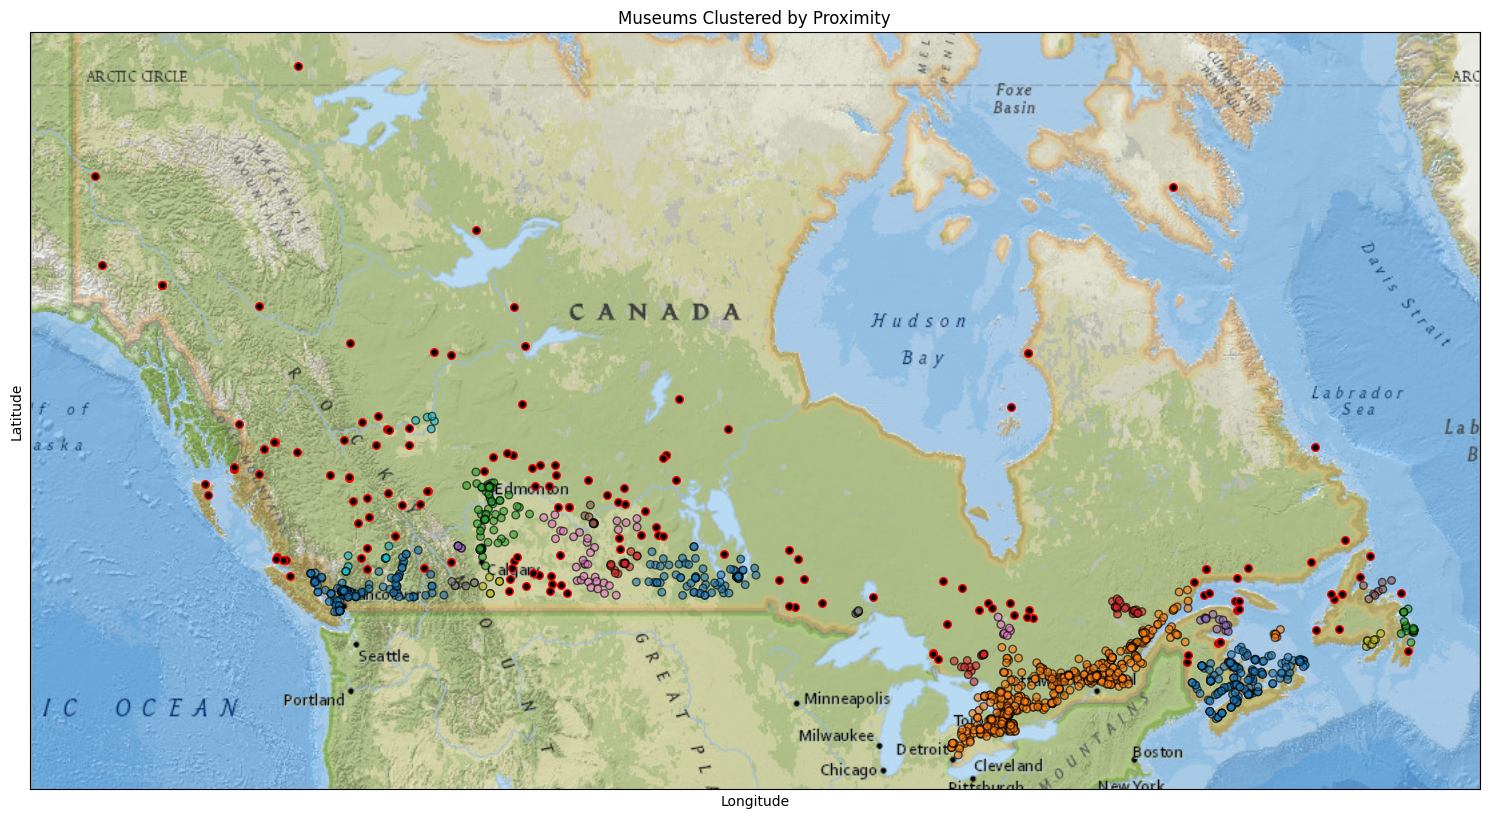

In [48]:
plot_clustered_locations(df, title='Museums Clustered by Proximity')

In [49]:
hdb = hdbscan.HDBSCAN(min_samples = None,min_cluster_size = 3,metric = 'euclidean')


In [53]:
hdb_predict = hdb.fit_predict(df_museum[['Latitude','Longitude']])
df['Cluster'] = hdb_predict
df['Cluster'].value_counts()

C:\Users\pavan b\AppData\Local\Temp\ipykernel_23056\1911308706.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = hdb_predict


Cluster
-1      471
 138     51
 80      39
 68      37
 63      28
       ... 
 136      3
 69       3
 59       3
 122      3
 20       3
Name: count, Length: 142, dtype: int64

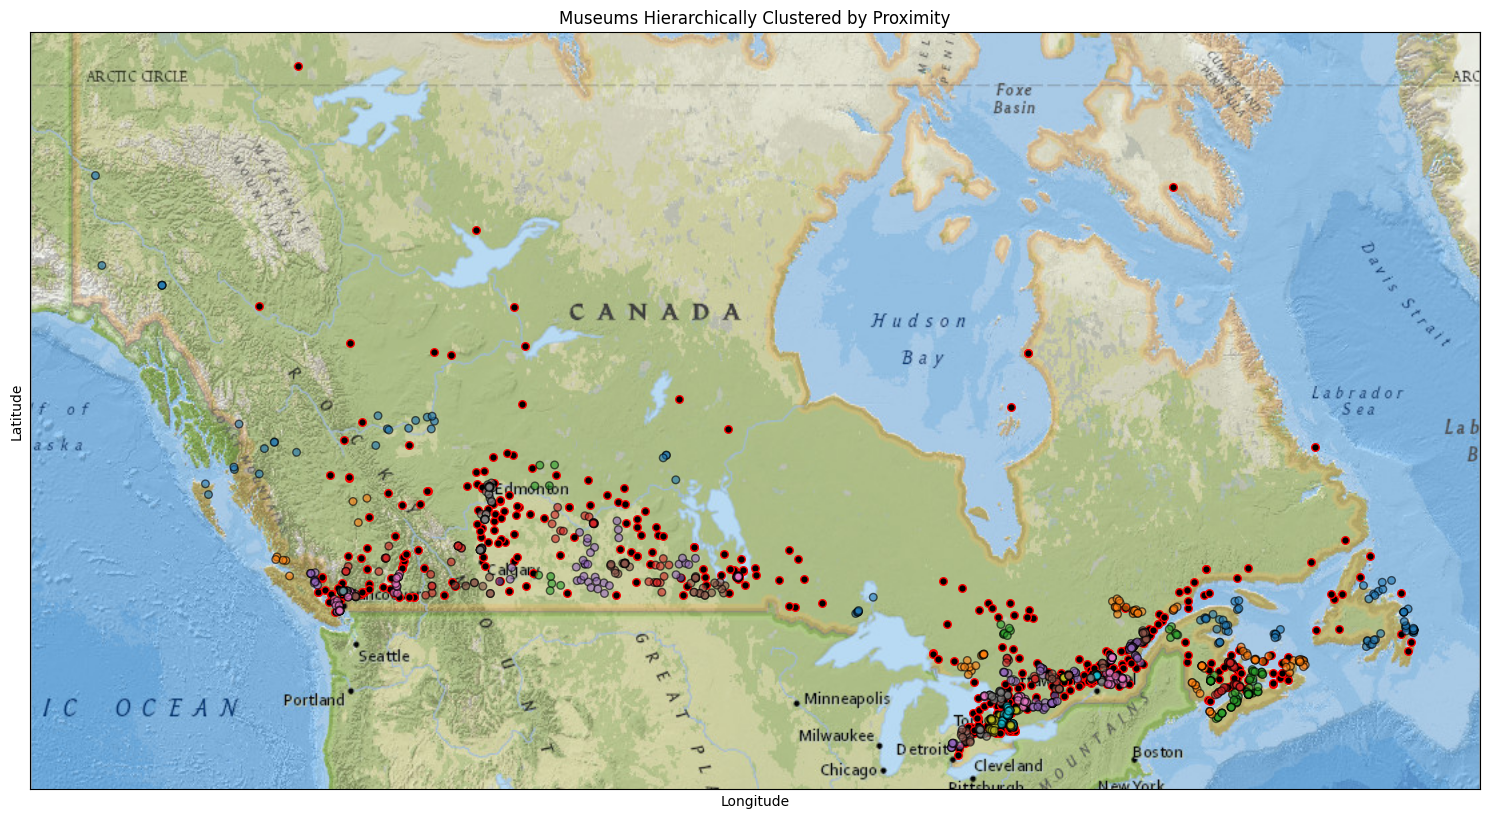

In [55]:
# Plot the museum clusters
plot_clustered_locations(df, title='Museums Hierarchically Clustered by Proximity')